For WRF/GFS workflows, cumulative rainfall is normally computed as:
    
    Accumulated Rainfall= sum {hourly rainfall increments}

or, more accurately in WRF:

    Accumulated Rainfall = (RAINC + RAINNC)_{t_2} - (RAINC + RAINNC)_{t_1}

Where:

RAINC = cumulative convective rainfall

RAINNC = cumulative non-convective (grid-scale) rainfall

Your wrfout contains all time steps internally. You simply select:

    first timestep
    last timestep

    and subtract them.

You usually plot:

Total accumulated rainfall = RAINC + RAINNC
difference between two times.

## 24-hr accumulated rainfall plot

In [1]:
# library imports
from wrf import getvar, latlon_coords, to_np
from netCDF4 import Dataset
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap, BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import numpy as np
import geopandas as gpd

In [2]:
# Dataset loading with wrf-python
ncfile = Dataset("wrfout_d01_2026-03-20_06:00:00")
counties = gpd.read_file("./map_shapefile_kenya/ke_shp/ke.shp")

In [3]:
print(counties.name)

0             Baringo
1               Bomet
2             Bungoma
3               Busia
4     Elgeyo-Marakwet
5                Embu
6             Garissa
7            Homa Bay
8              Isiolo
9             Kajiado
10           Kakamega
11            Kericho
12             Kiambu
13             Kilifi
14          Kirinyaga
15              Kisii
16             Kisumu
17              Kitui
18              Kwale
19           Laikipia
20               Lamu
21           Machakos
22            Makueni
23            Mandera
24           Marsabit
25               Meru
26             Migori
27            Mombasa
28           Murang'a
29            Nairobi
30              Nandi
31              Narok
32            Nyamira
33          Nyandarua
34              Nyeri
35            Samburu
36              Siaya
37       Taita Taveta
38         Tana River
39      Tharaka-Nithi
40        Trans Nzoia
41            Turkana
42        Uasin Gishu
43             Vihiga
44              Wajir
45        

In [4]:
# ======== CUMULATIVE RAINFALL  ============
#Get rainfall at start = time 0
rain_start = (getvar(ncfile, "RAINC", timeidx=0) + getvar(ncfile, "RAINNC", timeidx=0))

#Get rainfall at the end = time = 24
rain_end = (getvar(ncfile, "RAINC", timeidx=24) + getvar(ncfile, "RAINNC", timeidx=24))

# 24 hr rainfall accumulation
rain_accumulation = rain_end - rain_start

In [5]:
#  GET LATITUDES AND LONGTUDES 
lats , lons = latlon_coords(rain_accumulation)

In [6]:
# KMD LIKE COLORS AND LEVELS
colors = [
    "#c6f7d0",   # very light green
    "#7be495",   # light green
    "#3ac569",   # green
    "#f5f57a",   # yellow
    "#ffb347",   # orange
    "#ff7043",   # dark orange
    "#ff0000",   # red
    "#cc00cc",   # purple
    "#660066",   # dark purple
    "#ffffff"    # extreme
]

#  better rainfall levels for visualization
levels = [1, 5, 10, 20, 30, 40, 50, 75, 100, 150, 200] 

cmap = ListedColormap(colors)
norm = BoundaryNorm(levels, cmap.N)

/home/erickwambugu/miniconda3/envs/venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


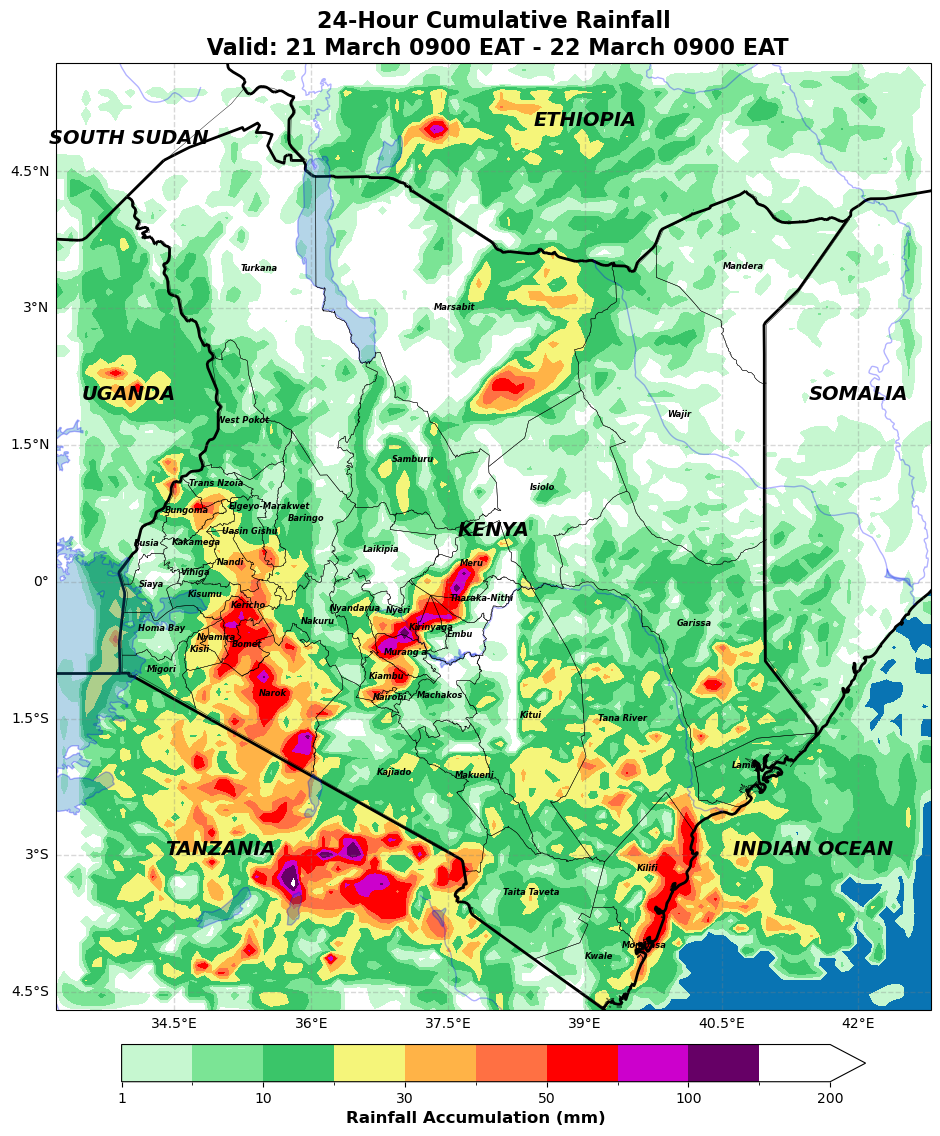

In [7]:
#  CREATE A FIGURE 
fig = plt.figure(figsize=(12, 15))
ax = plt.axes(projection=ccrs.PlateCarree())

# map fetures 
ax.add_feature(cfeature.BORDERS, edgecolor="black", linewidth=2)
ax.add_feature(cfeature.COASTLINE, linewidth=2)
ax.add_feature(cfeature.LAND, facecolor="white", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="#0974b3", zorder=0)
ax.add_feature(cfeature.LAKES, facecolor="#0974b3", edgecolor="blue", alpha=0.3)
ax.add_feature(cfeature.RIVERS, facecolor="#0974b3", edgecolor="blue", alpha=0.3)

# add counties 
counties.boundary.plot(ax=ax, edgecolor="black", linewidth=0.3, zorder=2)

# countries names
for idx, row in counties.iterrows():
    ax.text(
        row.geometry.centroid.x, 
        row.geometry.centroid.y, 
        row['name'], 
        transform=ccrs.PlateCarree(), 
        fontsize=6, 
        fontstyle='italic',
        fontweight='bold', 
        ha='center',
        zorder=4
    )

#  add countries names 
common_style = {
    'transform': ccrs.PlateCarree(), 
    'fontsize': 14, 
    'fontstyle': 'italic',
    'fontweight': 'bold', 
    'ha': 'center'
}

ax.text(38.0, 0.5, "KENYA", **common_style)
ax.text(42.0, 2.0, "SOMALIA", **common_style)
ax.text(39.0, 5.0, "ETHIOPIA", **common_style)
ax.text(34.0, 2.0, "UGANDA", **common_style)
ax.text(35.0, -3.0, "TANZANIA", **common_style)
ax.text(34.0, 4.8, "SOUTH SUDAN", **common_style)
ax.text(41.5, -3.0, "INDIAN OCEAN", **common_style)


#  adding gridlines 
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='gray', alpha=0.3, linestyle='--')

# Customize label appearance
gl.top_labels = False    # Turn off labels at the top
gl.right_labels = False  # Turn off labels on the right
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 10, 'color': 'black'}
gl.ylabel_style = {'size': 10, 'color': 'black'}


contour = ax.contourf(
    to_np(lons), 
    to_np(lats), 
    to_np(rain_accumulation),
    levels=levels, 
    cmap=cmap, 
    norm=norm,
    extend="max",
    transform=ccrs.PlateCarree()
)

cbar = plt.colorbar(
    contour,
    ax=ax,
    orientation="horizontal",
    pad=0.03,
    shrink=0.8
)

cbar.set_label("Rainfall Accumulation (mm)", fontsize=12, fontweight="bold")
cbar.ax.tick_params(labelsize=10)

plt.title("24-Hour Cumulative Rainfall\n Valid: 21 March 0900 EAT - 22 March 0900 EAT", fontsize=16, fontweight="bold")

# save the figure
plt.savefig("cumulative_rainfall.png", dpi=300, bbox_inches="tight")

plt.show()

# ANIMATION CODE -- CAN BE WRITTEN TO ANOTHER NOTEBOOK

In [8]:
#Get the total number of times we will loop through
ntimes = len(ncfile.dimensions['Time'])
print(f"Total time steps: {ntimes}")

Total time steps: 25


In [9]:
# get the initial rainfall accumulation at time 0, lats and lons 
rain_0 = (getvar(ncfile, "RAINC", timeidx=0) + getvar(ncfile, "RAINNC", timeidx=0))
lats , lons = latlon_coords(rain_0)

In [10]:
# extenxt lons and lats to the entire domain
lon_min = float(to_np(lons).min())
lon_max = float(to_np(lons).max())
lat_min = float(to_np(lats).min())
lat_max = float(to_np(lats).max())

/home/erickwambugu/miniconda3/envs/venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/erickwambugu/miniconda3/envs/venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/erickwambugu/miniconda3/envs/venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/erickwambugu/miniconda3/envs/venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/erickwambu

Animation saved as hourly_rainfall_animation.mp4


/home/erickwambugu/miniconda3/envs/venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


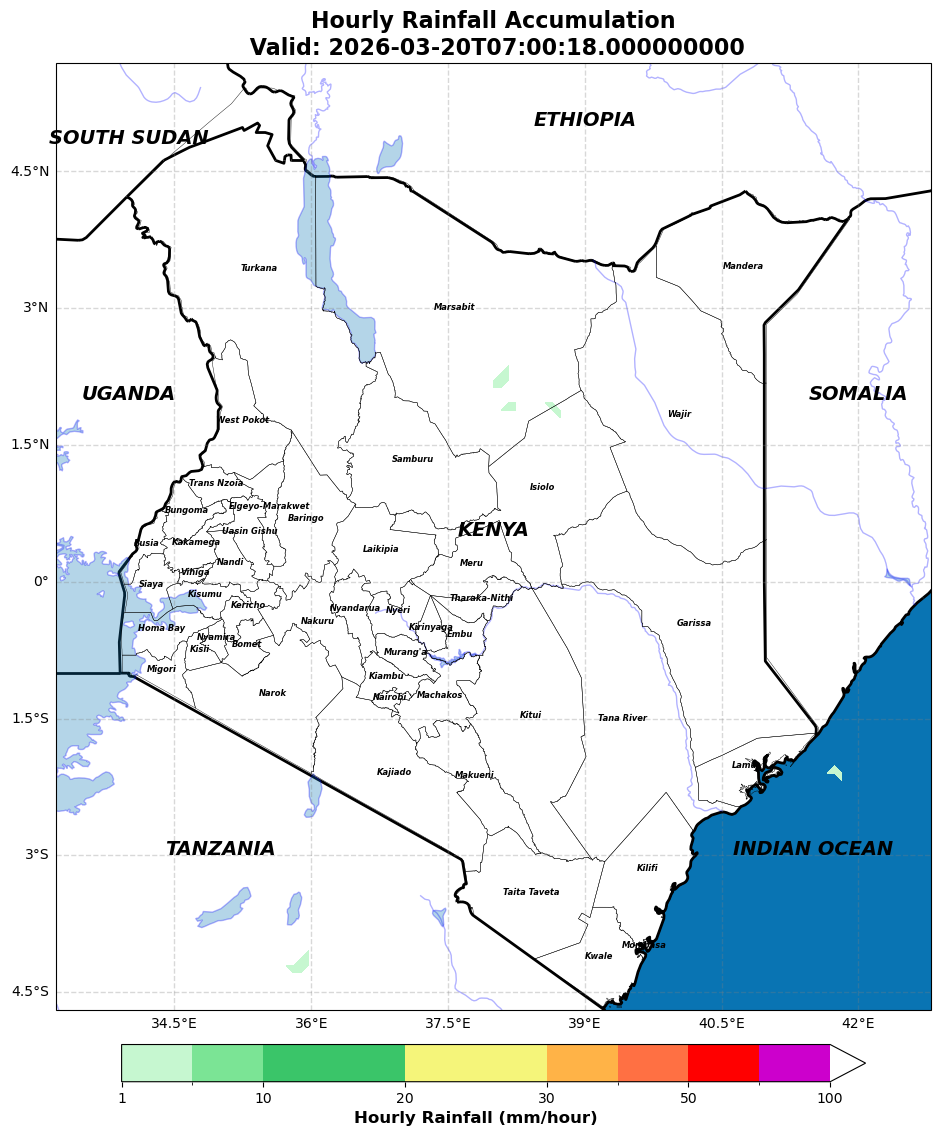

In [11]:
#  CREATE A FIGURE 
fig = plt.figure(figsize=(12, 15))
ax = plt.axes(projection=ccrs.PlateCarree())

# ======STATIC MAP FEATURES ======
# map fetures 
ax.add_feature(cfeature.BORDERS, edgecolor="black", linewidth=2)
ax.add_feature(cfeature.COASTLINE, linewidth=2)
ax.add_feature(cfeature.LAND, facecolor="white", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="#0974b3", zorder=0)
ax.add_feature(cfeature.LAKES, facecolor="#0974b3", edgecolor="blue", alpha=0.3)
ax.add_feature(cfeature.RIVERS, facecolor="#0974b3", edgecolor="blue", alpha=0.3)

# add counties 
counties.boundary.plot(ax=ax, edgecolor="black", linewidth=0.3, zorder=2)

# counties name 
for idx, row in counties.iterrows():
    ax.text(
        row.geometry.centroid.x, 
        row.geometry.centroid.y, 
        row['name'], 
        transform=ccrs.PlateCarree(), 
        fontsize=6, 
        fontstyle='italic',
        fontweight='bold', 
        ha='center',
        zorder=4
    )

#  add countries names 
common_style = {
    'transform': ccrs.PlateCarree(), 
    'fontsize': 14, 
    'fontstyle': 'italic',
    'fontweight': 'bold', 
    'ha': 'center'
}

ax.text(38.0, 0.5, "KENYA", **common_style)
ax.text(42.0, 2.0, "SOMALIA", **common_style)
ax.text(39.0, 5.0, "ETHIOPIA", **common_style)
ax.text(34.0, 2.0, "UGANDA", **common_style)
ax.text(35.0, -3.0, "TANZANIA", **common_style)
ax.text(34.0, 4.8, "SOUTH SUDAN", **common_style)
ax.text(41.5, -3.0, "INDIAN OCEAN", **common_style)


#  adding gridlines 
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='gray', alpha=0.3, linestyle='--')

# Customize label appearance
gl.top_labels = False    # Turn off labels at the top
gl.right_labels = False  # Turn off labels on the right
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 10, 'color': 'black'}
gl.ylabel_style = {'size': 10, 'color': 'black'}


# INITIAL PLOT BEFORE LOOPING THROUGH TIME STEPS
# ===== RAINFAL PLOT =========
levels = [1, 5, 10, 15, 20, 25, 30, 40, 50, 75, 100]

rain_plot = ax.contourf(
    to_np(lons),
    to_np(lats),
    np.zeros_like(to_np(rain_0)),  # Start with zero accumulation
    levels=levels, 
    cmap=cmap, 
    norm=norm,
    extend="max",
    transform=ccrs.PlateCarree()
)

# colorbar for the initial plot
cbar = plt.colorbar(
    rain_plot,
    ax=ax,
    orientation="horizontal",
    pad=0.03,
    shrink=0.8
)

cbar.set_label("Hourly Rainfall (mm/hour)", fontsize=12, fontweight="bold")
cbar.ax.tick_params(labelsize=10)


# ====== ANIMATION FUNCTION ======
def update_rainfall(frame):

    global rain_plot

    #  remove the previous contour plot
    ax.clear()
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())  # Set the extent of the map to focus on the region of interest
    ax.set_aspect("auto")  # Ensure the aspect ratio is maintained

    # Redraw the static map features
    ax.add_feature(cfeature.BORDERS, edgecolor="black", linewidth=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=2)
    ax.add_feature(cfeature.LAND, facecolor="white", zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor="#0974b3", zorder=0)
    ax.add_feature(cfeature.LAKES, facecolor="#0974b3", edgecolor="blue", alpha=0.3)
    ax.add_feature(cfeature.RIVERS, facecolor="#0974b3", edgecolor="blue", alpha=0.3)

    # add counties
    counties.boundary.plot(ax=ax, edgecolor="black", linewidth=0.3, zorder=2)

    # counties names 
    for idx, row in counties.iterrows():
        ax.text(
            row.geometry.centroid.x, 
            row.geometry.centroid.y, 
            row['name'], 
            transform=ccrs.PlateCarree(), 
            fontsize=6, 
            fontstyle='italic',
            fontweight='bold', 
            ha='center',
            zorder=4
        )

    #  add countries names 
    common_style = {
        'transform': ccrs.PlateCarree(), 
        'fontsize': 14, 
        'fontstyle': 'italic',
        'fontweight': 'bold', 
        'ha': 'center'
    }

    ax.text(38.0, 0.5, "KENYA", **common_style)
    ax.text(42.0, 2.0, "SOMALIA", **common_style)
    ax.text(39.0, 5.0, "ETHIOPIA", **common_style)
    ax.text(34.0, 2.0, "UGANDA", **common_style)
    ax.text(35.0, -3.0, "TANZANIA", **common_style)
    ax.text(34.0, 4.8, "SOUTH SUDAN", **common_style)
    ax.text(41.5, -3.0, "INDIAN OCEAN", **common_style)


    #   adding gridlines 
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='gray', alpha=0.3, linestyle='--')

    # Customize label appearance
    gl.top_labels = False    # Turn off labels at the top
    gl.right_labels = False  # Turn off labels on the right
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'color': 'black'}
    gl.ylabel_style = {'size': 10, 'color': 'black'}



    # get previous rainfall accumulation
    rain_prev = (getvar(ncfile, "RAINC", timeidx=frame) + getvar(ncfile, "RAINNC", timeidx=frame))

    # get current rainfall accumulation
    rain_now = (getvar(ncfile, "RAINC", timeidx=frame+1) + getvar(ncfile, "RAINNC", timeidx=frame+1))

    # Hourly rainfall accumulation
    rain_hourly = rain_now - rain_prev
    
    # mask zero rainfall values to improve visualization
    rain_hourly = np.ma.masked_less_equal(rain_hourly, 1)

    # plot the new rainfall accumulation
    rain_plot = ax.contourf(
        to_np(lons), 
        to_np(lats), 
        to_np(rain_hourly),
        levels=levels, 
        cmap=cmap, 
        norm=norm,
        extend="max",
        transform=ccrs.PlateCarree()
    )

    #  update the title of the plot with the current time step
    ax.set_title(f"Hourly Rainfall Accumulation\n Valid: {getvar(ncfile, 'Times', timeidx=frame+1).values}", fontsize=16, fontweight="bold")

    return []


# Create the animation
ani = animation.FuncAnimation(
    fig,
    update_rainfall,
    frames=ntimes-1,  # We have ntimes-1 hourly intervals
    blit=False,
    interval=1000,  # 1000 ms = 1 second per frame
)


#  save the animation as a mp4 video
ani.save("hourly_rainfall_animation.mp4", writer=animation.FFMpegWriter(fps=1), dpi=200)

print("Animation saved as hourly_rainfall_animation.mp4")